# 04 – Time–Height–Diameter Spectral Plots

Visualises the full bin-resolved spectra of cloud droplets (NW) and ice
crystals (NF) from the Zarr meteogram store.

Three dimensionality-reduction views:
1. **Time × Diameter** at selected height levels – spectral evolution.
2. **Height × Diameter** averaged over selected time windows – vertical
   distribution of the size spectrum.
3. **Time × Height** for diameter quantiles (D₁₀, D₅₀, D₉₀) – how
   characteristic sizes evolve.

In [2]:
import sys
from pathlib import Path

src_dir = next(p / "src" for p in (Path.cwd(), *Path.cwd().parents)
               if (p / "src" / "polarcap_runtime.py").is_file())
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from polarcap_runtime import is_server
import platform, socket
print("system:", platform.system(), platform.release())
print("hostname:", socket.gethostname())
print("is_server:", is_server())

system: Darwin 25.3.0
hostname: MacBookPro
is_server: False


In [3]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates

from utilities.plotting import create_new_jet3, create_fade_cmap, make_pastel
from utilities.meteogram_io import _compute_bin_coords

## Configuration

In [4]:
zarr_file = "Meteogram_cs-eriswil__20260304_110254_nVar136_nMet3_nExp5.zarr"
cs_run = "_".join(zarr_file.split("_")[1:5])

if is_server():
    root = Path("/work/bb1262/user/schimmel/cosmo-specs-torch/cosmo-specs-runs/RUN_ERISWILL_50x40x100")
    data_dir = root / "ensemble_output" / cs_run
else:
    data_dir = Path.home() / "data" / "cosmo-specs" / "meteograms" / cs_run

zarr_candidates = sorted(data_dir.glob("Meteogram_*.zarr"))
zarr_path = data_dir / zarr_file
print(f"Zarr store: {zarr_path}")

EXP_IDX = 1
STN_IDX = 1           # default station to plot
HEIGHT_LEVELS = [2, 5, 10, 15]   # indices to slice for time×diameter panels

TIME_FRAME = slice(np.datetime64("2023-01-25T12:15:00"), None)


Zarr store: /Users/schimmel/data/cosmo-specs/meteograms/cs-eriswil__20260304_110254/Meteogram_cs-eriswil__20260304_110254_nVar136_nMet3_nExp5.zarr


## Load data & build diameter coordinate

In [5]:
ds = xr.open_zarr(str(zarr_path))
ds_exp = ds.isel(expname=EXP_IDX)
ds_exp = ds_exp.sel(time=TIME_FRAME)

_exp_label = ds.expname.values[EXP_IDX]
exp_label = _exp_label.decode() if isinstance(_exp_label, bytes) else str(_exp_label)

n_stations = ds_exp.sizes["station"]
n_bins = ds_exp.sizes.get("bins", 66)

# build diameter coordinate from bin centres (metres → micrometres)
_, _, _, r_cen = _compute_bin_coords(n_bins=n_bins)
diameter_um = r_cen * 2 * 1e6  # µm
ds_exp = ds_exp.assign_coords(bins=("bins", diameter_um))
ds_exp = ds_exp.assign_coords(height_level=ds_exp.HMLd, height_level2=ds_exp.HHLd)

rho = ds_exp["RHO"] if "RHO" in ds_exp.data_vars else None
unit = r"cm$^{-3}$" if rho is not None else r"kg$^{-1}$"

print(f"Experiment: {exp_label}")
print(f"Stations: {n_stations}, bins: {n_bins}")
print(f"Diameter range: {diameter_um[0]:.3f} – {diameter_um[-1]:.1f} µm")

ds

Experiment: 20260304110638
Stations: 3, bins: 66
Diameter range: 0.002 – 7523.3 µm


<xarray.Dataset> Size: 37GB
Dimensions:              (expname: 5, station: 3, time: 4033, height_level: 20,
                          bins: 66, height_level2: 21, bins_boundaries: 67)
Coordinates: (12/14)
    station_lat          (station) float64 24B dask.array<chunksize=(3,), meta=np.ndarray>
    radius_centers       (bins) float64 528B dask.array<chunksize=(66,), meta=np.ndarray>
    HMLd                 (height_level) float32 80B dask.array<chunksize=(20,), meta=np.ndarray>
    station_lon          (station) float64 24B dask.array<chunksize=(3,), meta=np.ndarray>
  * height_level         (height_level) int64 160B 80 81 82 83 ... 96 97 98 99
  * height_level2        (height_level2) int64 168B 80 81 82 83 ... 97 98 99 100
    ...                   ...
    HHLd                 (height_level2) float32 84B dask.array<chunksize=(21,), meta=np.ndarray>
    radius_boundaries    (bins_boundaries) float64 536B dask.array<chunksize=(67,), meta=np.ndarray>
  * bins_boundaries      (bins_boundaries) int64 536B 0 1 2 3 4 ... 63 64 65 66
  * station              (station) int32 12B 1 2 3
  * expname              (expname) |S14 70B b'20260304110446' ... b'202603041...
    mass_centers         (bins) float64 528B dask.array<chunksize=(66,), meta=np.ndarray>
Dimensions without coordinates: bins
Data variables: (12/136)
    SUM_CONDNFROD        (expname, station, time, height_level, bins) float32 319MB dask.array<chunksize=(1, 3, 500, 20, 66), meta=np.ndarray>
    SUM_P_kollqwf        (expname, station, time, height_level, bins) float32 319MB dask.array<chunksize=(1, 3, 500, 20, 66), meta=np.ndarray>
    SUM_P_BREAN          (expname, station, time, height_level, bins) float32 319MB dask.array<chunksize=(1, 3, 500, 20, 66), meta=np.ndarray>
    SUM_P_dqfmelt        (expname, station, time, height_level, bins) float32 319MB dask.array<chunksize=(1, 3, 500, 20, 66), meta=np.ndarray>
    PML                  (expname, station, time, height_level) float32 5MB dask.array<chunksize=(1, 3, 500, 20), meta=np.ndarray>
    SUM_N_deponf         (expname, station, time, height_level, bins) float32 319MB dask.array<chunksize=(1, 3, 500, 20, 66), meta=np.ndarray>
    ...                   ...
    SUM_KOLLN            (expname, station, time, height_level, bins) float32 319MB dask.array<chunksize=(1, 3, 500, 20, 66), meta=np.ndarray>
    SUM_CONDQ            (expname, station, time, height_level, bins) float32 319MB dask.array<chunksize=(1, 3, 500, 20, 66), meta=np.ndarray>
    SUM_dqfmelt          (expname, station, time, height_level, bins) float32 319MB dask.array<chunksize=(1, 3, 500, 20, 66), meta=np.ndarray>
    T                    (expname, station, time, height_level) float32 5MB dask.array<chunksize=(1, 3, 500, 20), meta=np.ndarray>
    SUM_P_CONDN          (expname, station, time, height_level, bins) float32 319MB dask.array<chunksize=(1, 3, 500, 20, 66), meta=np.ndarray>
    SUM_dqffrier         (expname, station, time, height_level, bins) float32 319MB dask.array<chunksize=(1, 3, 500, 20, 66), meta=np.ndarray>

In [6]:
ds_exp.bins.values

array([2.25992105e-03, 2.84732210e-03, 3.58740105e-03, 4.51984210e-03,
       5.69464420e-03, 7.17480210e-03, 9.03968420e-03, 1.13892884e-02,
       1.43496042e-02, 1.80793684e-02, 2.27785768e-02, 2.86992084e-02,
       3.61587368e-02, 4.55571536e-02, 5.73984168e-02, 7.23174736e-02,
       9.11143073e-02, 1.14796834e-01, 1.44634947e-01, 1.82228615e-01,
       2.29593667e-01, 2.89269894e-01, 3.64457229e-01, 4.59187335e-01,
       5.78539789e-01, 7.28914458e-01, 9.18374669e-01, 1.15707958e+00,
       1.45782892e+00, 1.83674934e+00, 2.31415916e+00, 2.91565783e+00,
       3.67349868e+00, 4.62831831e+00, 5.83131566e+00, 7.34699735e+00,
       9.25663662e+00, 1.16626313e+01, 1.46939947e+01, 1.85132732e+01,
       2.33252627e+01, 2.93879894e+01, 3.70265465e+01, 4.66505253e+01,
       5.87759788e+01, 7.40530930e+01, 9.33010506e+01, 1.17551958e+02,
       1.48106186e+02, 1.86602101e+02, 2.35103915e+02, 2.96212372e+02,
       3.73204203e+02, 4.70207831e+02, 5.92424744e+02, 7.46408405e+02,
      

In [7]:
new_jet3 = create_new_jet3()
new_jet3_soft = create_fade_cmap(make_pastel(new_jet3, desaturation=0.25, darken=0.90), n_fade=2)

spectral_vars = [("NW", "Cloud droplet number"), ("NF", "Ice particle number")]
# keep only variables that exist
spectral_vars = [(v, lbl) for v, lbl in spectral_vars if v in ds_exp.data_vars]
print(f"Spectral variables: {[v for v, _ in spectral_vars]}")

Spectral variables: ['NW', 'NF']


# View 0 - Time-height of Bulk variables



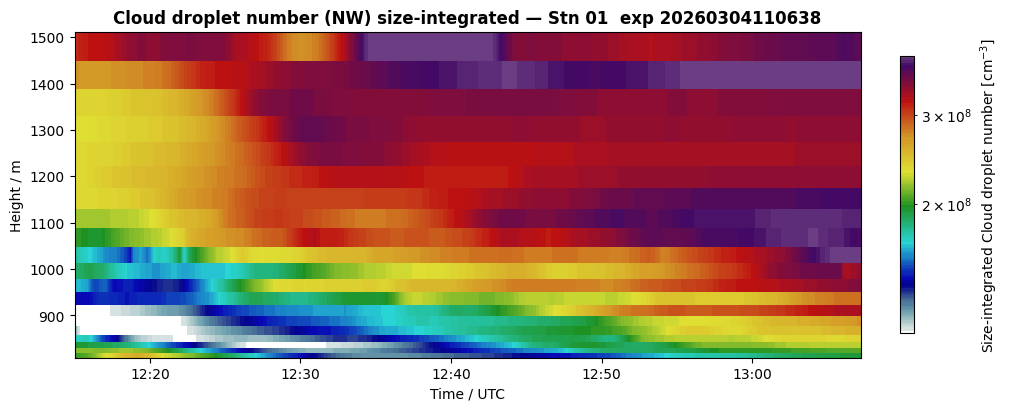

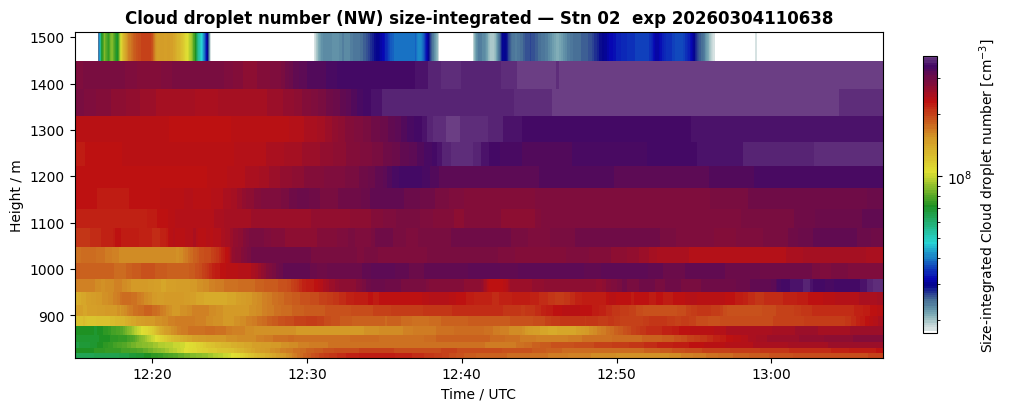

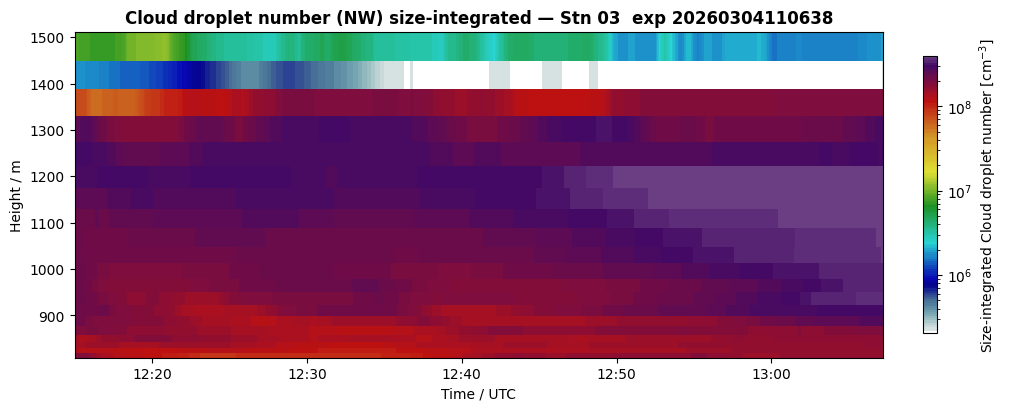

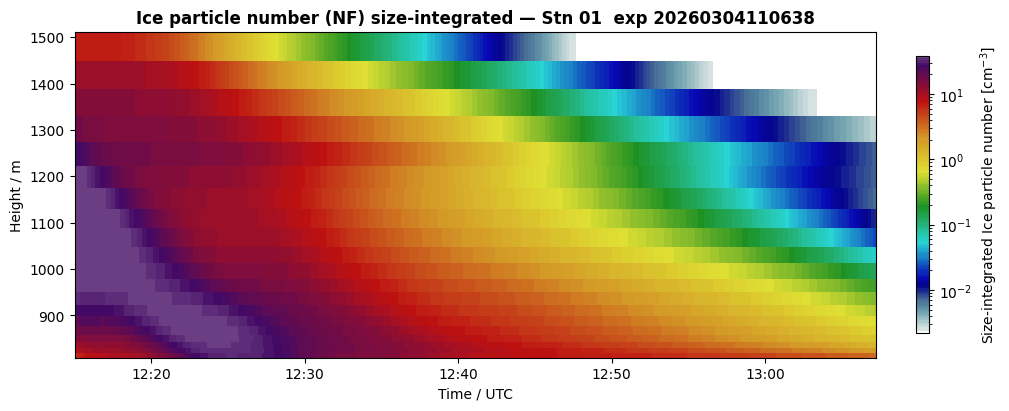

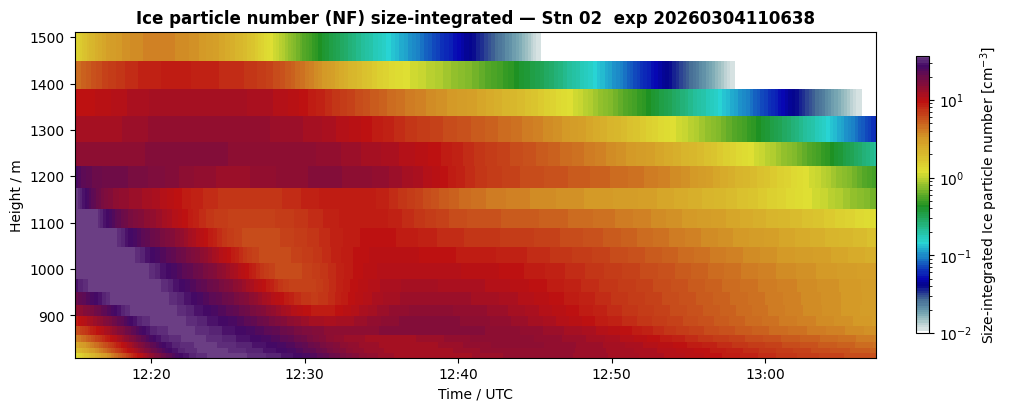

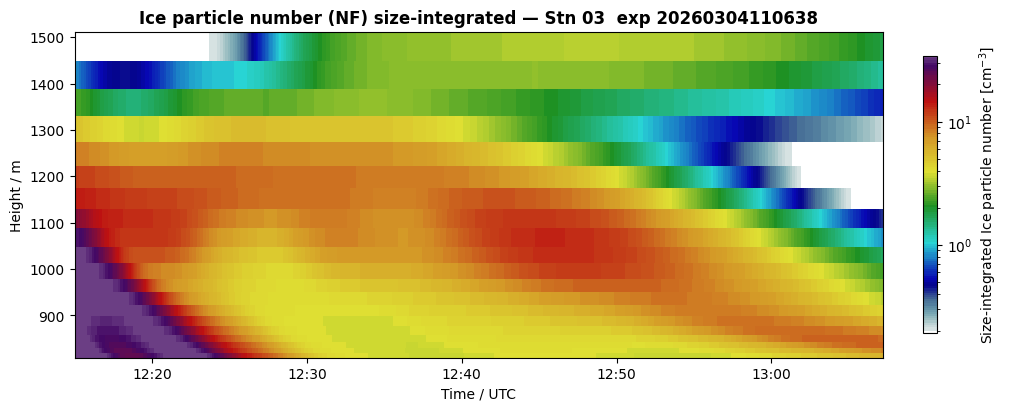

In [8]:
for varname, var_label in spectral_vars:
    for si in range(n_stations):
        sid = int(ds_exp.station.values[si])
        da = ds_exp[varname].isel(station=si)
        da = xr.where(da > 0, da, np.nan)
        da_col = da.isel(bins=slice(30, 50)).sum(dim="bins", skipna=True)


        d_vals = da_col.values.ravel()
        d_vals = d_vals[np.isfinite(d_vals) & (d_vals > 0)]
        if d_vals.size == 0:
            ax.set_title("No data")
            plt.show()
            continue

        fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
        vmin, vmax = np.nanpercentile(d_vals, [2, 98])
        vmin = max(vmin, 1e-6)
        norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)

        pcm = da_col.plot.pcolormesh(
            ax=ax, x="time", y="height_level",
            norm=norm, cmap=new_jet3_soft,
            add_colorbar=False, add_labels=False)

        ax.set_ylabel("Height / m")
        ax.set_xlabel("Time / UTC")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        fig.colorbar(pcm, ax=ax, label=f"Size-integrated {var_label} [{unit}]", shrink=0.85)

        ax.set_title(f"{var_label} ({varname}) size-integrated — Stn {sid:02d}  exp {exp_label}",
                     fontsize=12, fontweight="bold")
        plt.show()

## View 1a – Time × Diameter at selected height levels

For each spectral variable and station, a row of panels shows the size
distribution evolving in time at 4 representative heights.  The x-axis
is time, y-axis is diameter (log scale), colour is number concentration.

ValueError: y must be one of None, 'bins', 'expname', 'mass_centers', 'radius_centers', 'station', 'station_lat', 'station_lon', 'time'. Received 'diameter_um' instead.

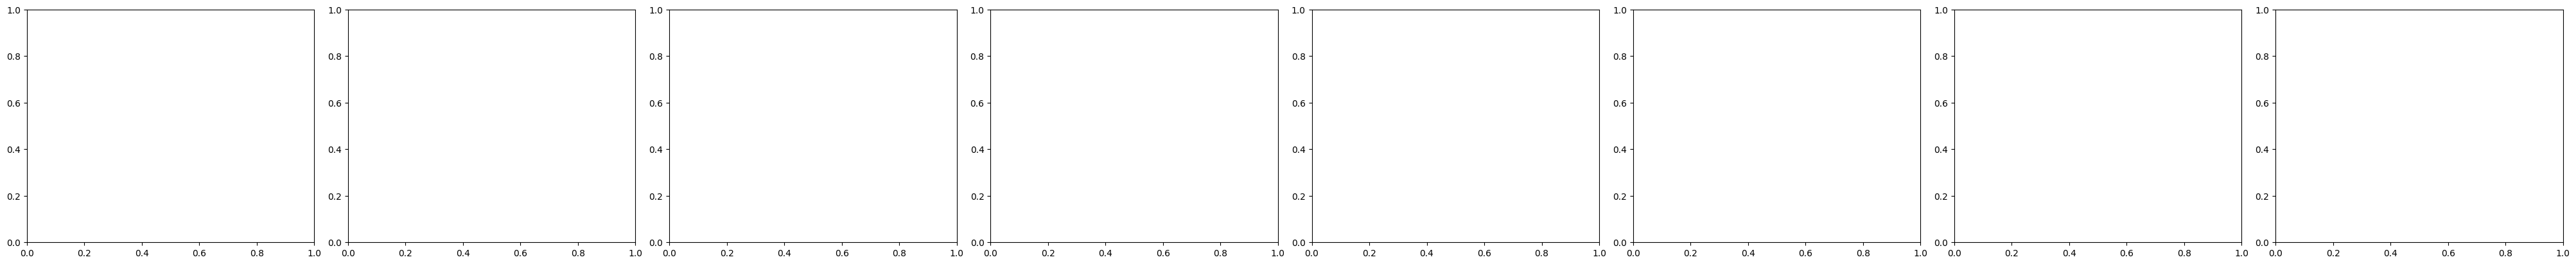

In [9]:

HEIGHT_RANGES = [(1350, 1275), (1275, 1200), (1200, 1125), (1125, 1050), (1050, 975), (975, 900), (900, 850), (850, 800)]


for varname, var_label in spectral_vars:
    for si in range(n_stations):
        sid = int(ds_exp.station.values[si])
        da = ds_exp[varname].isel(station=si)
        da = xr.where(da > 0, da, np.nan)

        n_hl = len(HEIGHT_RANGES)
        fig, axes = plt.subplots(1, n_hl, figsize=(n_hl * 5, 4), constrained_layout=True)
        axes = np.atleast_1d(axes)

        for idx, (ax, (h0, h1)) in enumerate(zip(axes, HEIGHT_RANGES)):
            da_hl = da.sel(height_level=slice(h0, h1)).mean(dim="height_level", skipna=True)
            d_vals = da_hl.values.ravel()
            d_vals = d_vals[np.isfinite(d_vals) & (d_vals > 0)]
            if d_vals.size == 0:
                ax.set_title(f"HL {h0:.0f}m – {h1:.0f}m: no data", fontsize=9)
                continue

            norm = mcolors.LogNorm()

            pcm = da_hl.plot.pcolormesh(
                ax=ax, x="time", y="diameter_um",
                norm=norm, cmap=new_jet3_soft, robust=True,
                add_colorbar=False, add_labels=False, yscale="log")

            ax.set_ylabel("Diameter [µm]" if idx == 0 else "")
            ax.set_xlabel("Time [UTC]")
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
            ax.set_title(f"Height level {h0:.0f}m – {h1:.0f}m", fontsize=9)
            fig.colorbar(pcm, ax=ax, label=f"{var_label} [{unit}]", shrink=0.85)

        fig.suptitle(f"{var_label} ({varname}) — Stn {sid:02d}  exp {exp_label}",
                     fontsize=13, fontweight="bold", y=1.06)
        plt.show()

## View 1.b – Column-integrated spectra over time

Summing along the height dimension gives the total column number
concentration per bin, showing how the overall droplet/ice size
distribution shifts over time.

In [ ]:
for varname, var_label in spectral_vars:
    for si in range(n_stations):
        sid = int(ds_exp.station.values[si])
        da = ds_exp[varname].isel(station=si)
        da = xr.where(da > 0, da, np.nan)
        da_col = da.sum(dim="height_level", skipna=True)


        d_vals = da_col.values.ravel()
        d_vals = d_vals[np.isfinite(d_vals) & (d_vals > 0)]
        if d_vals.size == 0:
            ax.set_title("No data")
            plt.show()
            continue

        fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
        vmin, vmax = np.nanpercentile(d_vals, [2, 98])
        vmin = max(vmin, 1e-6)
        norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)

        pcm = da_col.plot.pcolormesh(
            ax=ax, x="time", y="diameter_um",
            norm=norm, cmap=new_jet3_soft,
            add_colorbar=False, add_labels=False)

        ax.set_yscale("log")
        ax.set_ylabel("Diameter [µm]")
        ax.set_xlabel("Time [UTC]")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        fig.colorbar(pcm, ax=ax, label=f"Column-integrated {var_label} [{unit}]", shrink=0.85)

        ax.set_title(f"{var_label} ({varname}) column-integrated — Stn {sid:02d}  exp {exp_label}",
                     fontsize=12, fontweight="bold")
        plt.show()

## View 2 – Height × Diameter (time-averaged)

Averaging over selected time windows collapses the temporal axis and
reveals the vertical structure of the size distribution.  Two windows
are shown: the first and second halves of the simulation.

In [ ]:
TSTART_SEED = np.datetime64("2023-01-25T12:30:00")
TIME_WINDOWS = [(0.0, 0.25), (0.25, 0.5), (0.5, 1), (1, 2.5), (2.5, 5), (5, 7.5), (7.5, 10), (10, 15), (15, 25)] # in minutes after TSTART_SEED

for varname, var_label in spectral_vars:
    for si in range(n_stations):
        sid = int(ds_exp.station.values[si])
        da = ds_exp[varname].isel(station=si)
        da = xr.where(da > 0, da, np.nan)

        n_win = len(TIME_WINDOWS)
        fig, axes = plt.subplots(1, n_win, figsize=(n_win * 6, 5), constrained_layout=True)
        axes = np.atleast_1d(axes)

        for idx, (ax, (tw0, tw1)) in enumerate(zip(axes, TIME_WINDOWS)):
            t0 = TSTART_SEED + np.timedelta64(int(tw0*60), "s") if idx == 0 else t1
            t1 = TSTART_SEED + np.timedelta64(int(tw1*60), "s") 
            
            da_avg = da.sel(time=slice(t0, t1)).mean(dim="time", skipna=True)
            d_vals = d_vals[np.isfinite(d_vals) & (d_vals > 0)]
            if d_vals.size == 0:
                ax.set_title(f"{str(t0)[:10]} – {str(t1)[:10]}: no data", fontsize=9)
                continue

            norm = mcolors.LogNorm()
            pcm = da_avg.plot.pcolormesh(
                ax=ax, x="diameter_um", y="height_level",
                norm=norm, cmap=new_jet3_soft, robust=True,
                add_colorbar=False, add_labels=False, xscale="log")

            ax.set_xlabel("Diameter [µm]")
            ax.set_ylabel("Height level" if idx == 0 else "")
            ax.set_title(f"{str(t0)[:10]} – {str(t1)[:10]}", fontsize=10)
            fig.colorbar(pcm, ax=ax, label=f"{var_label} [{unit}]", shrink=0.85)

        fig.suptitle(f"{var_label} ({varname}) time-avg — Stn {sid:02d}  exp {exp_label}",
                     fontsize=13, fontweight="bold", y=1.02)
        plt.show()

## View 3 – Characteristic diameter evolution (time × height)

Instead of showing all bins, we reduce the spectral dimension to three
summary statistics: D₁₀, D₅₀ (median), and D₉₀ – the diameters below
which 10 %, 50 %, and 90 % of the total number concentration reside.
This captures how the distribution width and centre evolve over
`(time, height)`.

In [ ]:
def weighted_quantile_along_bins(da, diameter_um, quantiles):
    """Compute diameter quantiles from the spectral distribution.

    For each (time, height) cell, treats the bin values as weights and
    finds the diameter at which the cumulative weight crosses each quantile.
    Returns a dict {q_label: DataArray(time, height_level)}.
    """
    vals = da.values  # (time, height_level, bins)
    diam = diameter_um  # (bins,)
    result = {q: np.full(vals.shape[:2], np.nan) for q in quantiles}

    for ti in range(vals.shape[0]):
        for hi in range(vals.shape[1]):
            w = vals[ti, hi, :]
            if np.all(np.isnan(w)) or np.nansum(w) == 0:
                continue
            w = np.nan_to_num(w, nan=0.0)
            cumw = np.cumsum(w)
            cumw /= cumw[-1]  # normalise to [0, 1]
            for q in quantiles:
                idx = np.searchsorted(cumw, q)
                idx = min(idx, len(diam) - 1)
                result[q][ti, hi] = diam[idx]

    out = {}
    for q in quantiles:
        label = f"D{int(q * 100)}"
        out[label] = xr.DataArray(
            result[q], dims=("time", "height_level"),
            coords={"time": da.coords["time"], "height_level": da.coords["height_level"]},
        )
    return out


quantiles = [0.10, 0.50, 0.90]

for varname, var_label in spectral_vars:
    for si in range(n_stations):
        sid = int(ds_exp.station.values[si])
        da = ds_exp[varname].isel(station=si)
        da = xr.where(da > 0, da, 0.0)

        dq = weighted_quantile_along_bins(da, diameter_um, quantiles)

        fig, axes = plt.subplots(1, len(dq), figsize=(len(dq) * 5, 4), constrained_layout=True)
        axes = np.atleast_1d(axes)

        for idx, (qlabel, dq_da) in enumerate(dq.items()):
            ax = axes[idx]
            d_vals = dq_da.values.ravel()
            d_vals = d_vals[np.isfinite(d_vals) & (d_vals > 0)]
            if d_vals.size == 0:
                ax.set_title(f"{qlabel}: no data")
                continue

            norm = mcolors.LogNorm(vmin=diameter_um[0], vmax=diameter_um[-1])
            pcm = dq_da.plot.pcolormesh(
                ax=ax, x="time", y="height_level",
                norm=norm, cmap=new_jet3_soft, robust=True,
                add_colorbar=False, add_labels=False)

            ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
            ax.set_xlabel("Time [UTC]")
            ax.set_ylabel("Height level" if idx == 0 else "")
            ax.set_title(f"{qlabel} diameter", fontsize=10)
            fig.colorbar(pcm, ax=ax, label="Diameter [µm]", shrink=0.85)

        fig.suptitle(f"{var_label} ({varname}) diameter quantiles — Stn {sid:02d}  exp {exp_label}",
                     fontsize=13, fontweight="bold", y=1.06)
        plt.show()